## Model vs Market Forward — 2030 Comparison

Comparing PyPSA model results (`solved_baseline6.nc`, CY2009) against **2030 market forward data**.

**Data sources:**
- Model: `../scenarios/baseline_networks/solved_baseline6.nc` — PyPSA LP dispatch, CY2009
- `Prices.xlsx` — monthly TTF gas + EUA CO₂ forward curves
- `LT model.xlsx` — monthly electricity price forecast: DE + 10 neighbouring countries
- `LT model 2.xlsx / Fundamentals` — monthly DE generation by tech + net imports [MWh]

**Important caveat:** Market forward reflects expected 2030 conditions under a composite/average climate year.
Our model uses **CY2009** (specific weather year — above-average wind, below-average solar).
Wind/solar generation differences partly reflect this — price and thermal dispatch comparisons are more meaningful.

**Sections:**
1. Input price assumptions — Gas TTF and CO₂ EUA (model vs market)
2. Monthly LMP — DE00 (model vs market forward)
3. Monthly LMP — multi-country (model vs LT model price forecast)
4. Monthly DE generation by technology (model vs market forward)
5. DE net imports by neighbour (model vs market forward)

In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

NETWORK_FILE = "../scenarios/baseline_networks/solved_baseline6.nc"
MKT_DIR      = "../od miskufa/rediplomovprcastav"
PRICES_XLS   = f"{MKT_DIR}/Prices.xlsx"
LT1_XLS      = f"{MKT_DIR}/LT model.xlsx"
LT2_XLS      = f"{MKT_DIR}/LT model 2.xlsx"
MONTH_NAMES  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
BUS          = "DE00"

# Model baseline assumptions
MODEL_GAS_PRICE = 22.68   # EUR/MWh_th
MODEL_CO2_PRICE = 113.4   # EUR/tCO2

CAT_COLORS = {
    "Nuclear":          "#7B2D8B",
    "Lignite":          "#5D4037",
    "Coal":             "#795548",
    "Gas":              "#F57F17",   # all gas variants → single colour
    "Oil":              "#B71C1C",
    "Other Thermal":    "#78909C",
    "Hydro Reservoir":  "#0D47A1",
    "Hydro RoR":        "#1565C0",
    "Hydro PHS":        "#42A5F5",
    "Wind Onshore":     "#388E3C",
    "Wind Offshore":    "#1B5E20",
    "Solar PV":         "#FDD835",
    "Battery":          "#00ACC1",
    "Hydrogen":         "#AB47BC",
    "Other RES":        "#66BB6A",
    "DSR":              "#FF7043",
}
CAT_ORDER = [
    "Nuclear", "Lignite", "Coal", "Gas", "Oil", "Other Thermal",
    "Hydro Reservoir", "Hydro RoR", "Hydro PHS",
    "Wind Onshore", "Wind Offshore", "Solar PV",
    "Battery", "Hydrogen", "Other RES", "DSR",
]
PYPSA_CAT = {
    "nuclear":                  "Nuclear",
    "lignite":                  "Lignite",
    "coal":                     "Coal",
    "gas":                      "Gas",        # all gas → Gas
    "gas-ccs":                  "Gas",
    "oil-light":                "Oil",
    "oil-heavy":                "Oil",
    "oil-shale":                "Oil",
    "hydro-ror":                "Hydro RoR",
    "hydro-reservoir":          "Hydro Reservoir",
    "hydro-pondage":            "Hydro Reservoir",
    "hydro-phs":                "Hydro PHS",
    "hydro-phs-pure":           "Hydro PHS",
    "offwind":                  "Wind Offshore",
    "onwind":                   "Wind Onshore",
    "solar-pv-utility":         "Solar PV",
    "solar-pv-rooftop":         "Solar PV",
    "solar-thermal":            "Solar PV",
    "solar-thermal-w-storage":  "Solar PV",
    "other-res":                "Other RES",
    "other-thermal":            "Other Thermal",
    "battery":                  "Battery",
    "h2-ccgt":                  "Hydrogen",
    "h2-fuel-cell":             "Hydrogen",
    "dsr":                      "DSR",
    "slack":                    None,
}

n = pypsa.Network(NETWORK_FILE)
print(f"Loaded: {len(n.buses)} buses | {len(n.snapshots)} h")
print(f"Period: {n.snapshots[0]} — {n.snapshots[-1]}")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Loaded: 55 buses | 8760 h
Period: 2030-01-01 00:00:00 — 2030-12-31 23:00:00


## Section 1 — Input Price Assumptions: Gas TTF & CO₂ EUA

Model uses single-point annual prices; market provides monthly forward curves for 2030.

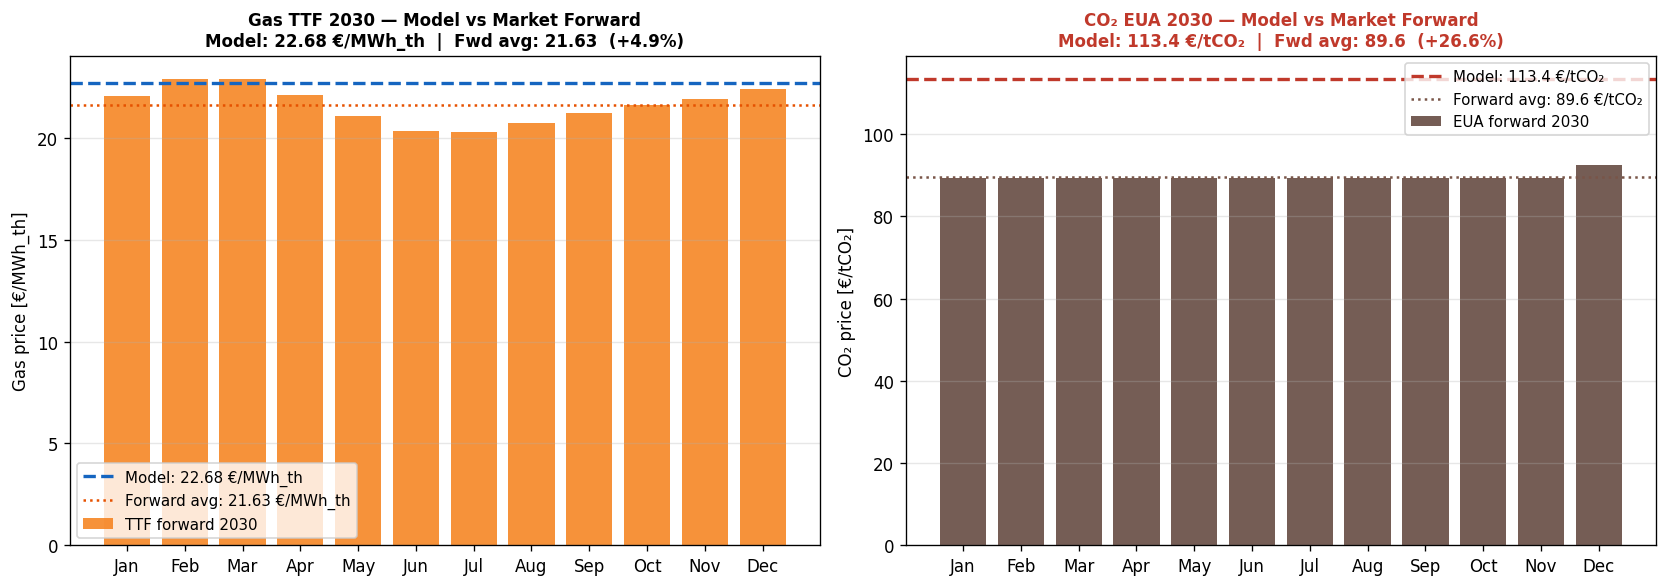

Gas TTF  model=22.68  fwd_avg=21.63  diff=+1.05 (+4.9%)
CO2 EUA  model=113.4   fwd_avg=89.6   diff=+23.8  (+26.6%)


In [2]:
# Gas TTF
gas_raw = pd.read_excel(PRICES_XLS, sheet_name="Gas", header=None, engine="openpyxl")
gas_raw.columns = gas_raw.iloc[0]
gas_raw = gas_raw.iloc[1:].reset_index(drop=True)
gas_raw["Date"] = pd.to_datetime(gas_raw["Date"])
gas_raw["TTF"]  = pd.to_numeric(gas_raw["TTF"], errors="coerce")
gas_2030 = gas_raw[gas_raw["Date"].dt.year == 2030].reset_index(drop=True)
ttf_avg  = gas_2030["TTF"].mean()

# CO2 EUA
co2_raw = pd.read_excel(PRICES_XLS, sheet_name="Carbon", header=None, engine="openpyxl")
co2_raw = co2_raw.iloc[1:].reset_index(drop=True)
co2_raw[0] = pd.to_datetime(co2_raw[0])
co2_raw[1] = pd.to_numeric(co2_raw[1], errors="coerce")
co2_2030 = co2_raw[co2_raw[0].dt.year == 2030].reset_index(drop=True)
eua_avg  = co2_2030[1].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(12), gas_2030["TTF"].values, color="#F57F17", alpha=0.85, label="TTF forward 2030")
ax1.axhline(MODEL_GAS_PRICE, color="#1565C0", linewidth=2, linestyle="--",
            label=f"Model: {MODEL_GAS_PRICE} €/MWh_th")
ax1.axhline(ttf_avg, color="#E65100", linewidth=1.5, linestyle=":",
            label=f"Forward avg: {ttf_avg:.2f} €/MWh_th")
ax1.set_xticks(range(12)); ax1.set_xticklabels(MONTH_NAMES)
ax1.set_ylabel("Gas price [€/MWh_th]")
ax1.set_title(
    f"Gas TTF 2030 — Model vs Market Forward\n"
    f"Model: {MODEL_GAS_PRICE} €/MWh_th  |  Fwd avg: {ttf_avg:.2f}  "
    f"({100*(MODEL_GAS_PRICE-ttf_avg)/ttf_avg:+.1f}%)",
    fontsize=10, fontweight="bold"
)
ax1.legend(fontsize=9); ax1.grid(axis="y", alpha=0.3)

ax2.bar(range(12), co2_2030[1].values, color="#5D4037", alpha=0.85, label="EUA forward 2030")
ax2.axhline(MODEL_CO2_PRICE, color="#c0392b", linewidth=2, linestyle="--",
            label=f"Model: {MODEL_CO2_PRICE} €/tCO₂")
ax2.axhline(eua_avg, color="#795548", linewidth=1.5, linestyle=":",
            label=f"Forward avg: {eua_avg:.1f} €/tCO₂")
ax2.set_xticks(range(12)); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel("CO₂ price [€/tCO₂]")
ax2.set_title(
    f"CO₂ EUA 2030 — Model vs Market Forward\n"
    f"Model: {MODEL_CO2_PRICE} €/tCO₂  |  Fwd avg: {eua_avg:.1f}  "
    f"({100*(MODEL_CO2_PRICE-eua_avg)/eua_avg:+.1f}%)",
    fontsize=10, fontweight="bold", color="#c0392b"
)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Gas TTF  model={MODEL_GAS_PRICE:.2f}  fwd_avg={ttf_avg:.2f}  diff={MODEL_GAS_PRICE-ttf_avg:+.2f} ({100*(MODEL_GAS_PRICE-ttf_avg)/ttf_avg:+.1f}%)")
print(f"CO2 EUA  model={MODEL_CO2_PRICE:.1f}   fwd_avg={eua_avg:.1f}   diff={MODEL_CO2_PRICE-eua_avg:+.1f}  ({100*(MODEL_CO2_PRICE-eua_avg)/eua_avg:+.1f}%)")

## Section 2 — Monthly LMP: DE00 Model vs Market Forward

- **Market:** `LT model 2.xlsx` Fundamentals col 1 — monthly price [€/MWh] for 2030
- **Model:** monthly average of `buses_t.marginal_price['DE00']`

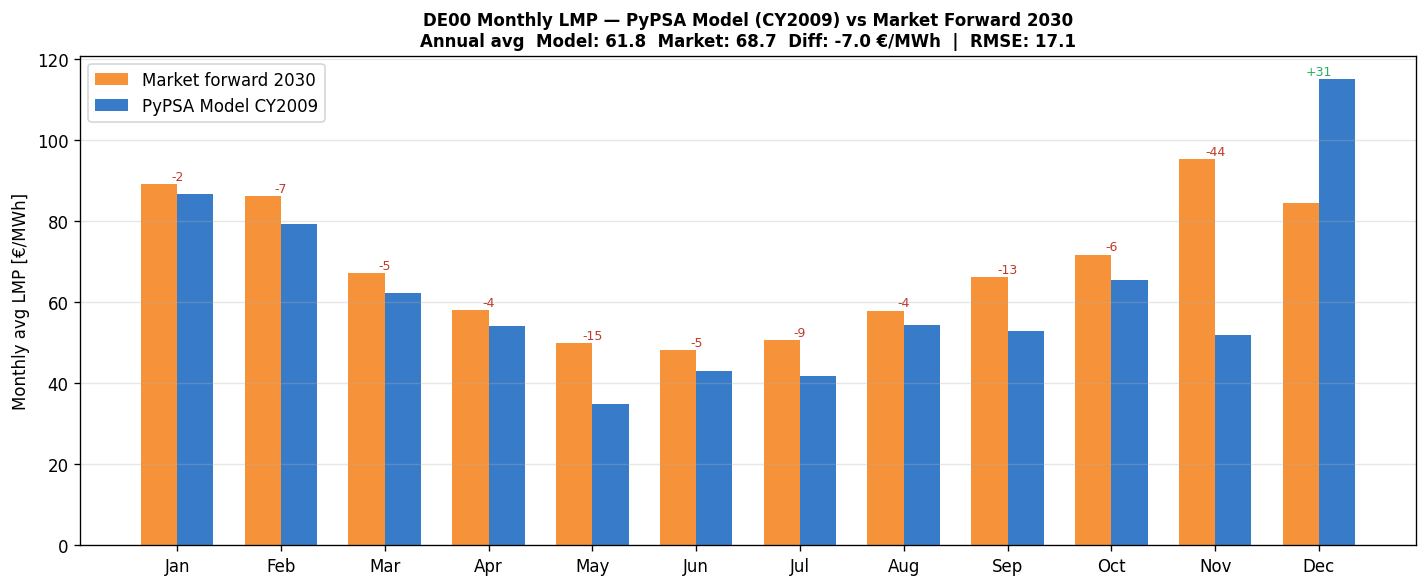


Month   Market    Model     Diff   Diff%
----------------------------------------
Jan      89.16    86.76    -2.40   -2.7%
Feb      86.06    79.34    -6.72   -7.8%
Mar      67.26    62.18    -5.08   -7.5%
Apr      57.92    54.00    -3.92   -6.8%
May      49.87    34.80   -15.07  -30.2%
Jun      48.17    42.91    -5.26  -10.9%
Jul      50.54    41.79    -8.75  -17.3%
Aug      57.91    54.28    -3.63   -6.3%
Sep      66.28    52.79   -13.49  -20.3%
Oct      71.72    65.40    -6.32   -8.8%
Nov      95.38    51.87   -43.51  -45.6%
Dec      84.31   114.98   +30.67  +36.4%
Avg      68.71    61.76    -6.96  -10.1%


In [3]:
# Load LT model 2 Fundamentals — shared across sections 2, 4, 5
fund_raw  = pd.read_excel(LT2_XLS, sheet_name="Fundamentals", header=None, engine="openpyxl")
fund_dates = pd.to_datetime(fund_raw.iloc[:, 0], errors="coerce")
fund_2030  = fund_raw[fund_dates.dt.year == 2030].copy().reset_index(drop=True)

mkt_price_monthly = pd.to_numeric(fund_2030.iloc[:, 1], errors="coerce").values

# Model monthly LMP
model_lmp_de = n.buses_t.marginal_price[BUS]
model_lmp_monthly = np.array([float(model_lmp_de[model_lmp_de.index.month == m + 1].mean())
                               for m in range(12)])
diffs = model_lmp_monthly - mkt_price_monthly

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(12); w = 0.35
ax.bar(x - w/2, mkt_price_monthly, width=w, color="#F57F17", alpha=0.85, label="Market forward 2030")
ax.bar(x + w/2, model_lmp_monthly,  width=w, color="#1565C0", alpha=0.85, label="PyPSA Model CY2009")
for xi, d in enumerate(diffs):
    ax.text(xi, max(mkt_price_monthly[xi], model_lmp_monthly[xi]) + 1,
            f"{d:+.0f}", ha="center", fontsize=7.5,
            color="#27ae60" if d > 0 else "#c0392b")
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Monthly avg LMP [€/MWh]")
ax.set_title(
    f"{BUS} Monthly LMP — PyPSA Model (CY2009) vs Market Forward 2030\n"
    f"Annual avg  Model: {model_lmp_monthly.mean():.1f}  Market: {mkt_price_monthly.mean():.1f}  "
    f"Diff: {diffs.mean():+.1f} €/MWh  |  RMSE: {np.sqrt(np.mean(diffs**2)):.1f}",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Month':<5} {'Market':>8} {'Model':>8} {'Diff':>8} {'Diff%':>7}")
print("-" * 40)
for i, mon in enumerate(MONTH_NAMES):
    t, m, d = mkt_price_monthly[i], model_lmp_monthly[i], diffs[i]
    pct = 100 * d / t if t != 0 else float("nan")
    print(f"{mon:<5} {t:8.2f} {m:8.2f} {d:+8.2f} {pct:+6.1f}%")
avg_pct = 100 * diffs.mean() / mkt_price_monthly.mean()
print(f"{'Avg':<5} {mkt_price_monthly.mean():8.2f} {model_lmp_monthly.mean():8.2f} {diffs.mean():+8.2f} {avg_pct:+6.1f}%")

## Section 3 — Monthly LMP: Multi-Country

`LT model.xlsx` `Price Forecast` has monthly 2030 forecasts for 11 countries (DEU, FRA, NLD, BEL, AUT, GBR, ESP, PRT, ITA, POL, CZE).

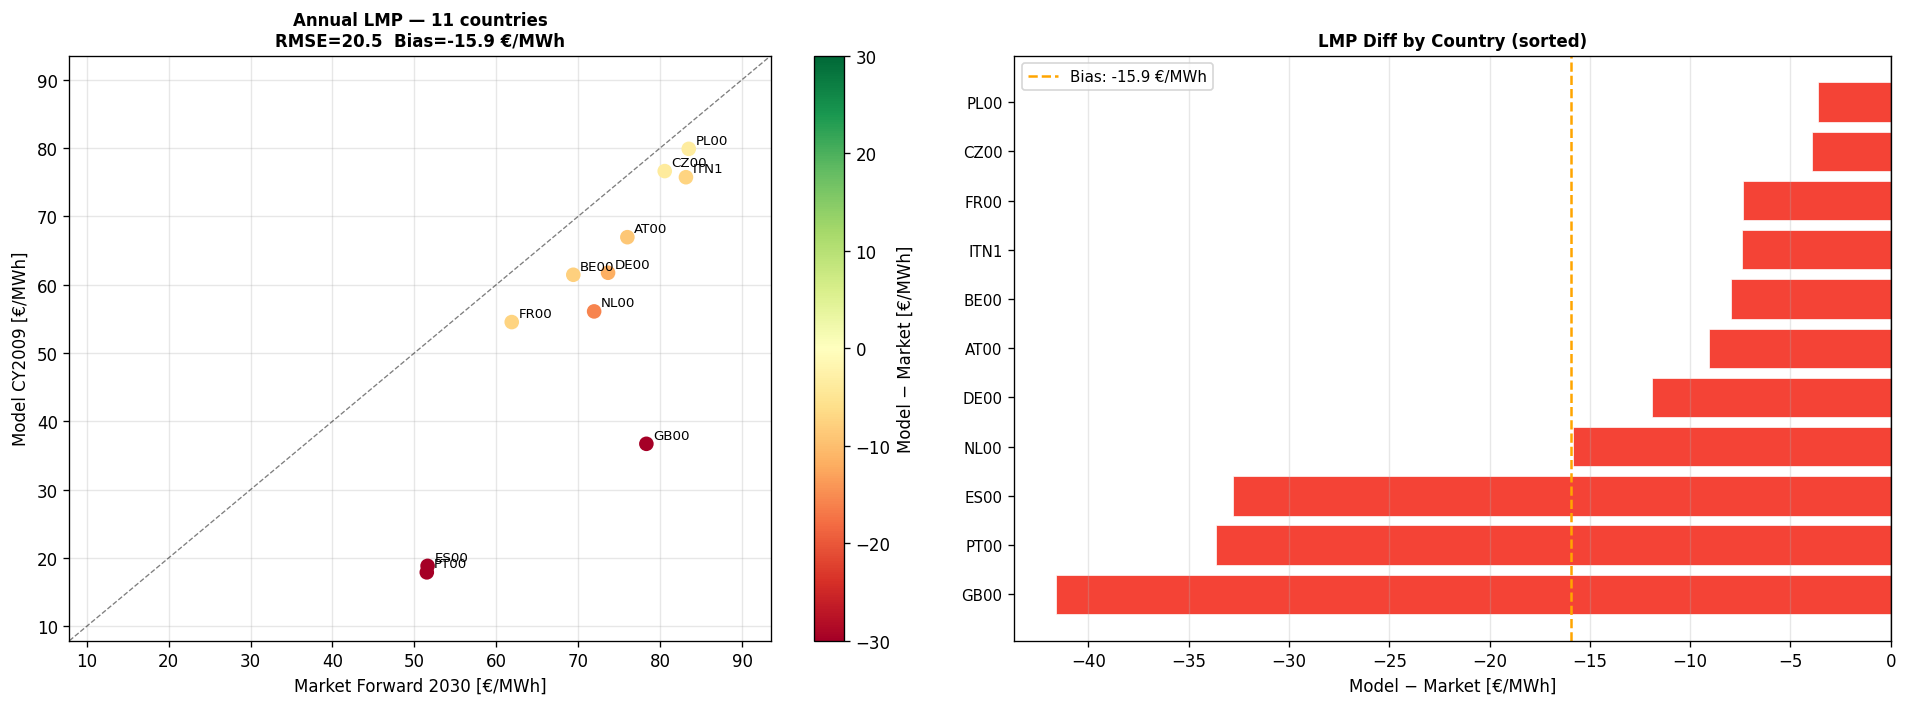


Bus      Market    Model     Diff   Diff%
----------------------------------------
AT00      76.00    66.95    -9.05  -11.9%
BE00      69.40    61.45    -7.95  -11.5%
CZ00      80.56    76.62    -3.94   -4.9%
DE00      73.64    61.74   -11.90  -16.2%
ES00      51.61    18.84   -32.77  -63.5%
FR00      61.88    54.52    -7.36  -11.9%
GB00      78.32    36.70   -41.62  -53.1%
ITN1      83.15    75.72    -7.43   -8.9%
NL00      71.94    56.08   -15.86  -22.0%
PL00      83.49    79.87    -3.62   -4.3%
PT00      51.51    17.89   -33.62  -65.3%


In [4]:
pf_raw = pd.read_excel(LT1_XLS, sheet_name="Price Forecast", header=None, engine="openpyxl")
pf_raw.columns = pf_raw.iloc[0]
pf_raw = pf_raw.iloc[1:].reset_index(drop=True)
pf_raw["Date"] = pd.to_datetime(pf_raw["Date"])
for col in pf_raw.columns[1:]:
    pf_raw[col] = pd.to_numeric(pf_raw[col], errors="coerce")
pf_2030 = pf_raw[pf_raw["Date"].dt.year == 2030].reset_index(drop=True)

COUNTRY_MAP = {
    "DEU": "DE00", "FRA": "FR00", "NLD": "NL00", "BEL": "BE00",
    "AUT": "AT00", "GBR": "GB00", "ESP": "ES00", "PRT": "PT00",
    "ITA": "ITN1", "POL": "PL00", "CZE": "CZ00",
}
mkt_annual   = {bus: float(pf_2030[lc].mean()) for lc, bus in COUNTRY_MAP.items() if lc in pf_2030.columns}
model_annual = {bus: float(n.buses_t.marginal_price[bus].mean())
                for bus in COUNTRY_MAP.values() if bus in n.buses_t.marginal_price.columns}
common = sorted(set(mkt_annual) & set(model_annual))

t_vals  = np.array([mkt_annual[b]   for b in common])
m_vals  = np.array([model_annual[b] for b in common])
diffs_c = m_vals - t_vals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

pad = 10
lims = [min(t_vals.min(), m_vals.min()) - pad, max(t_vals.max(), m_vals.max()) + pad]
ax1.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
sc = ax1.scatter(t_vals, m_vals, c=diffs_c, cmap="RdYlGn", vmin=-30, vmax=30, s=60, zorder=3)
plt.colorbar(sc, ax=ax1, label="Model − Market [€/MWh]")
for i, b in enumerate(common):
    ax1.annotate(b, (t_vals[i], m_vals[i]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax1.set_xlabel("Market Forward 2030 [€/MWh]")
ax1.set_ylabel("Model CY2009 [€/MWh]")
ax1.set_title(
    f"Annual LMP — {len(common)} countries\n"
    f"RMSE={np.sqrt(np.mean(diffs_c**2)):.1f}  Bias={diffs_c.mean():+.1f} €/MWh",
    fontsize=10, fontweight="bold"
)
ax1.set_xlim(lims); ax1.set_ylim(lims); ax1.grid(alpha=0.3)

order   = np.argsort(diffs_c)
buses_s = [common[i] for i in order]
diffs_s = diffs_c[order]
ax2.barh(range(len(buses_s)), diffs_s,
         color=["#2196F3" if d >= 0 else "#F44336" for d in diffs_s],
         edgecolor="white", linewidth=0.4)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.axvline(diffs_c.mean(), color="orange", linestyle="--", linewidth=1.5,
            label=f"Bias: {diffs_c.mean():+.1f} €/MWh")
ax2.set_yticks(range(len(buses_s))); ax2.set_yticklabels(buses_s, fontsize=9)
ax2.set_xlabel("Model − Market [€/MWh]")
ax2.set_title("LMP Diff by Country (sorted)", fontsize=10, fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Bus':<6} {'Market':>8} {'Model':>8} {'Diff':>8} {'Diff%':>7}")
print("-" * 40)
for b in sorted(common):
    t, m = mkt_annual[b], model_annual[b]
    d = m - t
    pct = 100 * d / t if t != 0 else float("nan")
    print(f"{b:<6} {t:8.2f} {m:8.2f} {d:+8.2f} {pct:+6.1f}%")

## Section 4 — Monthly DE Generation by Technology

- **Market forward:** Fundamentals generation block (cols 4–17), MWh/month → TWh
- **Model:** DE00 monthly generation aggregated by category

Column mapping: 4=Battery, 5=Hydrogen, 6=Solar, 7=Wind Onshore, 8=Wind Offshore, 9=Other (→Other RES),
10=Hydro, 11=Bio (→Other RES), 12=CCS Gas (→Gas CCGT), 13=Gas, 14=Coal, 15=Oil, 16=Lignite, 17=Nuclear.

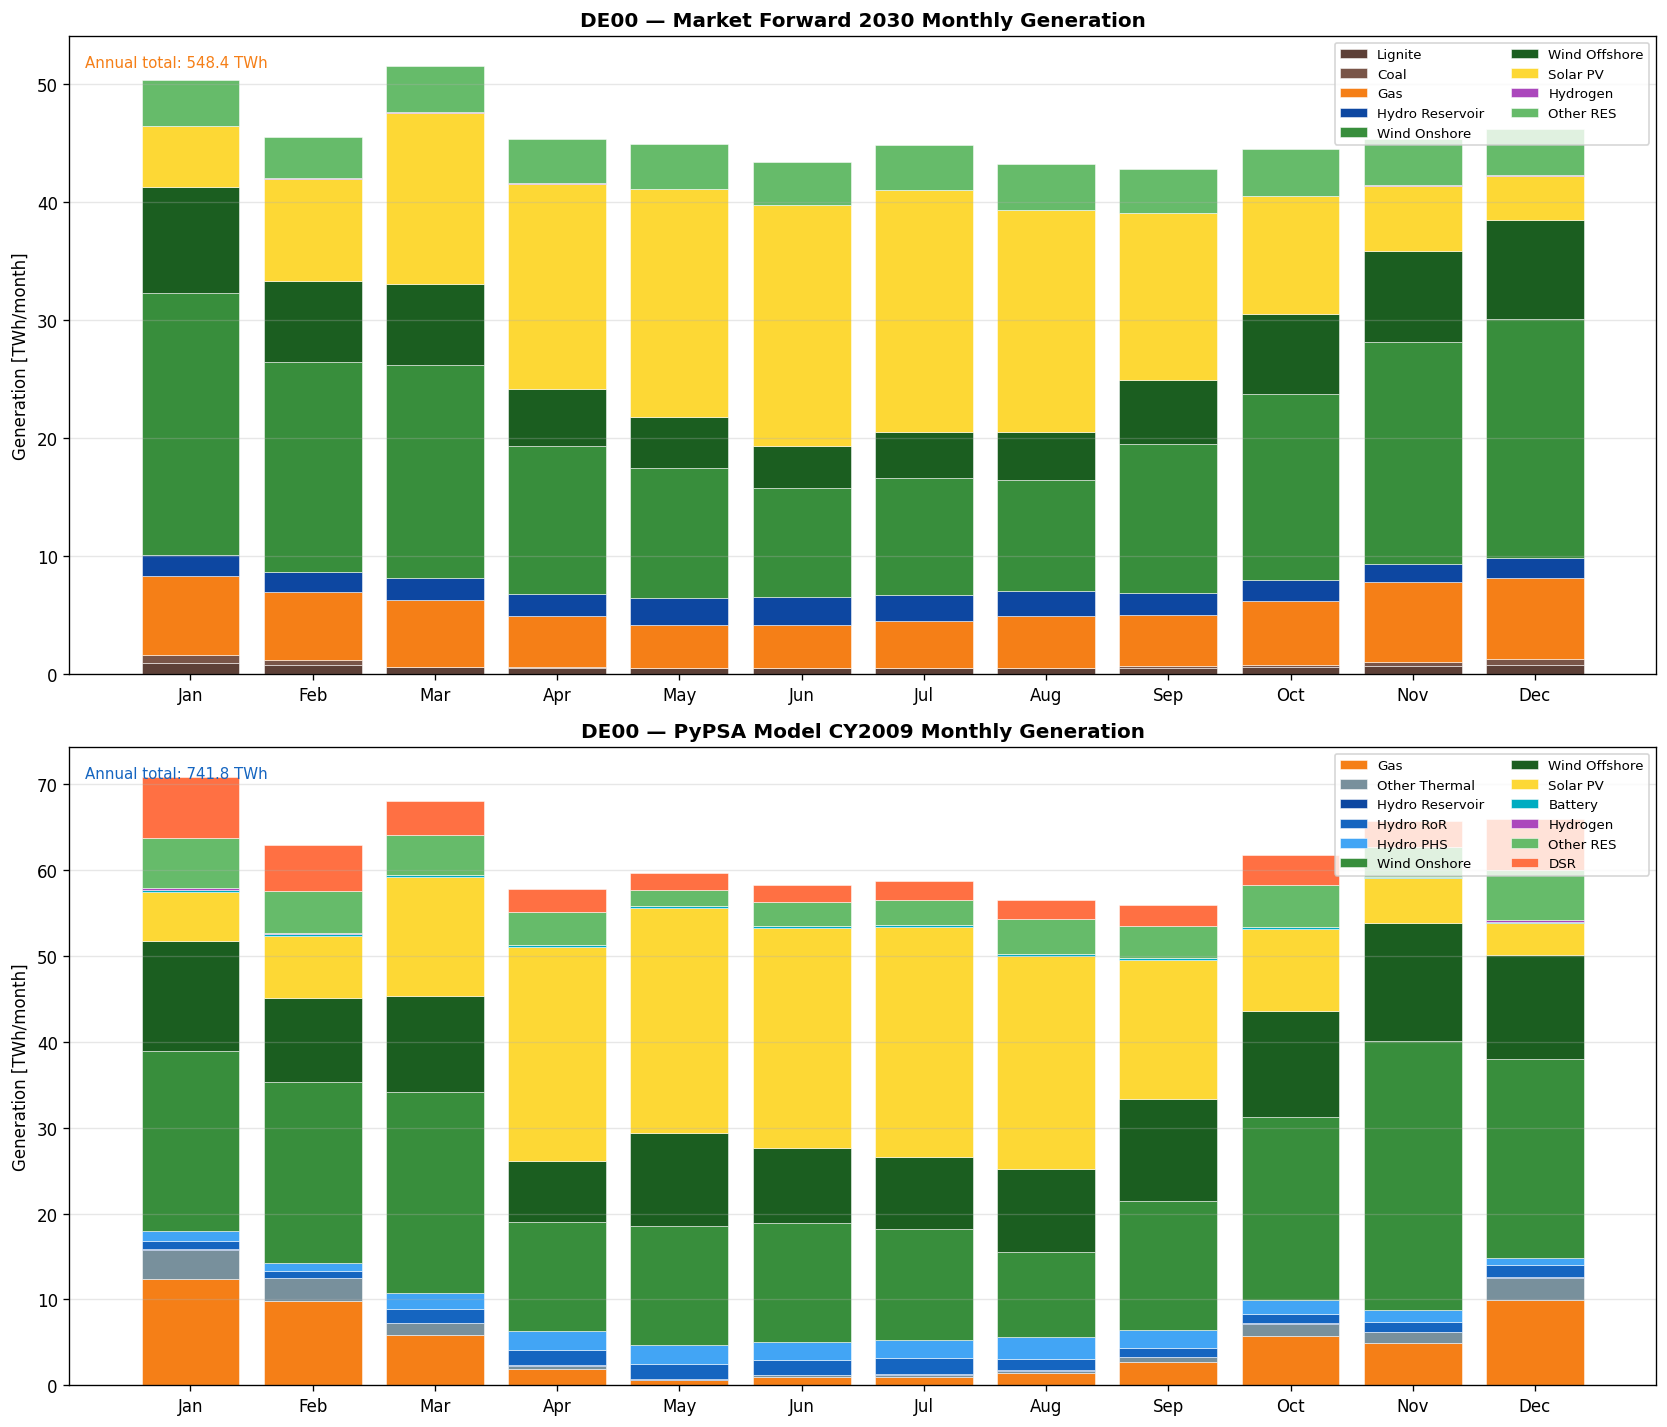


DE00 annual generation by category:
  Category                Market TWh   Model TWh     Diff   Diff%
  ------------------------------------------------------------
  Lignite                       7.70        0.00    -7.70 -100.0%  !
  Coal                          2.29        0.00    -2.29 -100.0%  !
  Gas                          61.68       57.15    -4.53   -7.3%
  Other Thermal                 0.00       14.47   +14.47   +nan%
  Hydro Reservoir              22.97        0.60   -22.37  -97.4%  !
  Hydro RoR                     0.00       16.77   +16.77   +nan%
  Hydro PHS                     0.00       20.95   +20.95   +nan%
  Wind Onshore                177.80      219.38   +41.58  +23.4%
  Wind Offshore                71.69      128.46   +56.76  +79.2%  !
  Solar PV                    158.14      189.69   +31.55  +20.0%
  Battery                       0.00        2.63    +2.63   +nan%
  Hydrogen                      0.37        0.69    +0.32   +nan%
  Other RES                   

In [5]:
GEN_COLS = {
    4:  "Battery",
    5:  "Hydrogen",
    6:  "Solar PV",
    7:  "Wind Onshore",
    8:  "Wind Offshore",
    9:  "Other RES",
    10: "Hydro Reservoir",
    11: "Other RES",     # Bio → Other RES
    12: "Gas",           # CCS Gas → Gas
    13: "Gas",           # Gas → Gas
    14: "Coal",
    15: "Oil",
    16: "Lignite",
    17: "Nuclear",
}

# Market monthly gen [TWh]
mkt_de_monthly = {}
for ci, cat in GEN_COLS.items():
    vals = pd.to_numeric(fund_2030.iloc[:, ci], errors="coerce").fillna(0).clip(lower=0).values
    mkt_de_monthly[cat] = mkt_de_monthly.get(cat, np.zeros(12)) + vals / 1e6

# Model monthly gen DE00 [TWh]
model_de_monthly = {}
for gen_id, g in n.generators.iterrows():
    if g["bus"] != BUS or gen_id not in n.generators_t.p.columns: continue
    cat = PYPSA_CAT.get(g["carrier"])
    if cat is None: continue
    ts = n.generators_t.p[gen_id]
    model_de_monthly.setdefault(cat, np.zeros(12))
    for mo in range(12):
        model_de_monthly[cat][mo] += float(ts[ts.index.month == mo + 1].sum()) / 1e6

for su_id, s in n.storage_units.iterrows():
    if s["bus"] != BUS or su_id not in n.storage_units_t.p.columns: continue
    cat = PYPSA_CAT.get(s["carrier"])
    if cat is None: continue
    ts = n.storage_units_t.p[su_id].clip(lower=0)
    model_de_monthly.setdefault(cat, np.zeros(12))
    for mo in range(12):
        model_de_monthly[cat][mo] += float(ts[ts.index.month == mo + 1].sum()) / 1e6

cats_mkt   = [c for c in CAT_ORDER if c in mkt_de_monthly   and max(mkt_de_monthly[c])   > 0.05]
cats_model = [c for c in CAT_ORDER if c in model_de_monthly and max(model_de_monthly[c]) > 0.05]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
x = np.arange(12)

bottom = np.zeros(12)
for cat in cats_mkt:
    h = mkt_de_monthly[cat]
    ax1.bar(x, h, bottom=bottom, color=CAT_COLORS.get(cat, "#9E9E9E"),
            label=cat, edgecolor="white", linewidth=0.3)
    bottom += h
ax1.set_xticks(x); ax1.set_xticklabels(MONTH_NAMES)
ax1.set_ylabel("Generation [TWh/month]")
ax1.set_title(f"{BUS} — Market Forward 2030 Monthly Generation", fontweight="bold")
ax1.legend(fontsize=8, loc="upper right", ncol=2); ax1.grid(axis="y", alpha=0.3)
ax1.text(0.01, 0.97, f"Annual total: {bottom.sum():.1f} TWh",
         transform=ax1.transAxes, va="top", fontsize=9, color="#F57F17")

bottom2 = np.zeros(12)
for cat in cats_model:
    h = model_de_monthly[cat]
    ax2.bar(x, h, bottom=bottom2, color=CAT_COLORS.get(cat, "#9E9E9E"),
            label=cat, edgecolor="white", linewidth=0.3)
    bottom2 += h
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel("Generation [TWh/month]")
ax2.set_title(f"{BUS} — PyPSA Model CY2009 Monthly Generation", fontweight="bold")
ax2.legend(fontsize=8, loc="upper right", ncol=2); ax2.grid(axis="y", alpha=0.3)
ax2.text(0.01, 0.97, f"Annual total: {bottom2.sum():.1f} TWh",
         transform=ax2.transAxes, va="top", fontsize=9, color="#1565C0")

plt.tight_layout(); plt.show()

all_cats_t = sorted(set(cats_mkt) | set(cats_model),
                    key=lambda c: CAT_ORDER.index(c) if c in CAT_ORDER else 99)
print(f"\n{BUS} annual generation by category:")
print(f"  {'Category':<22} {'Market TWh':>11} {'Model TWh':>11} {'Diff':>8} {'Diff%':>7}")
print("  " + "-" * 60)
for cat in all_cats_t:
    t = mkt_de_monthly.get(cat, np.zeros(12)).sum()
    m = model_de_monthly.get(cat, np.zeros(12)).sum()
    d = m - t
    pct = 100 * d / t if t > 0.5 else float("nan")
    flag = "  !" if not np.isnan(pct) and abs(pct) > 25 else ""
    print(f"  {cat:<22} {t:11.2f} {m:11.2f} {d:+8.2f} {pct:+6.1f}%{flag}")
print(f"  {'TOTAL':<22} {bottom.sum():11.2f} {bottom2.sum():11.2f} {bottom2.sum()-bottom.sum():+8.2f}")

## Section 5 — DE Net Imports by Neighbour

- **Market:** Fundamentals import block cols 43–53 (AT, BE, CH, CZ, DK, FR, NL, NO, PL, SE, UK) [MWh/month]
- **Model:** computed from AC line and DC link flows

Positive = net import **to** DE (DE is net importer from that country).

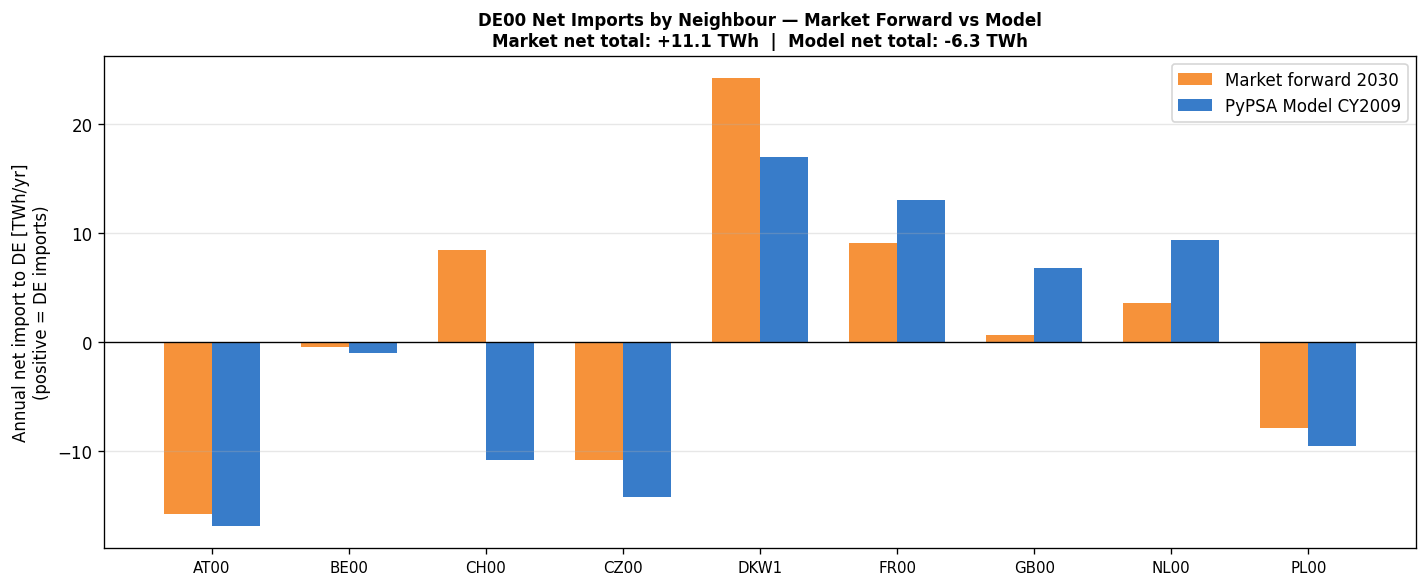


Neighbour  Market TWh   Model TWh     Diff   Diff%
--------------------------------------------------
AT00          -15.79      -16.91    -1.12   -7.1%
BE00           -0.48       -0.98    -0.50 -102.4%
CH00            8.46      -10.85   -19.31 -228.3%
CZ00          -10.84      -14.22    -3.38  -31.2%
DKW1           24.26       17.05    -7.21  -29.7%
FR00            9.12       13.03    +3.91  +42.9%
GB00            0.67        6.78    +6.11 +913.3%
NL00            3.61        9.34    +5.73 +158.6%
PL00           -7.87       -9.55    -1.68  -21.4%
Net total       11.13       -6.32   -17.45


In [6]:
IMP_COLS = {
    43: "AT00", 44: "BE00", 45: "CH00", 46: "CZ00", 47: "DKW1",
    48: "FR00", 49: "NL00", 50: "NO00", 51: "PL00", 52: "SE00", 53: "GB00",
}

# Market annual net import to DE [TWh]
mkt_imp = {}
for ci, nbr in IMP_COLS.items():
    vals = pd.to_numeric(fund_2030.iloc[:, ci], errors="coerce").fillna(0)
    mkt_imp[nbr] = float(vals.sum()) / 1e6

# Model: net export FROM DE (flip sign → net import TO DE)
model_exp = {}
for line in n.lines.index:
    b0, b1 = n.lines.at[line, "bus0"], n.lines.at[line, "bus1"]
    if b0 != BUS and b1 != BUS: continue
    if line not in n.lines_t.p0.columns: continue
    flow = float(n.lines_t.p0[line].sum()) / 1e6
    nbr  = b1 if b0 == BUS else b0
    sign = 1 if b0 == BUS else -1
    model_exp[nbr] = model_exp.get(nbr, 0.0) + sign * flow

for link in n.links.index:
    b0, b1 = n.links.at[link, "bus0"], n.links.at[link, "bus1"]
    if b0 != BUS and b1 != BUS: continue
    if link not in n.links_t.p0.columns: continue
    p0 = float(n.links_t.p0[link].sum()) / 1e6
    p1 = float(n.links_t.p1[link].sum()) / 1e6
    if b0 == BUS:
        nbr = b1; model_exp[nbr] = model_exp.get(nbr, 0.0) + p0
    else:
        nbr = b0; model_exp[nbr] = model_exp.get(nbr, 0.0) + p1

model_imp = {nbr: -v for nbr, v in model_exp.items()}

common_nbrs = sorted(set(mkt_imp) & set(model_imp))
t_imp = np.array([mkt_imp[nb]   for nb in common_nbrs])
m_imp = np.array([model_imp[nb] for nb in common_nbrs])

x = np.arange(len(common_nbrs)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, t_imp, width=w, color="#F57F17", alpha=0.85, label="Market forward 2030")
ax.bar(x + w/2, m_imp, width=w, color="#1565C0", alpha=0.85, label="PyPSA Model CY2009")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(common_nbrs, fontsize=9)
ax.set_ylabel("Annual net import to DE [TWh/yr]\n(positive = DE imports)")
ax.set_title(
    f"DE00 Net Imports by Neighbour — Market Forward vs Model\n"
    f"Market net total: {t_imp.sum():+.1f} TWh  |  Model net total: {m_imp.sum():+.1f} TWh",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Neighbour':<8} {'Market TWh':>11} {'Model TWh':>11} {'Diff':>8} {'Diff%':>7}")
print("-" * 50)
for nb, t, m in zip(common_nbrs, t_imp, m_imp):
    d = m - t
    pct = 100 * d / abs(t) if t != 0 else float("nan")
    print(f"{nb:<8} {t:11.2f} {m:11.2f} {d:+8.2f} {pct:+6.1f}%")
print(f"{'Net total':<8} {t_imp.sum():11.2f} {m_imp.sum():11.2f} {m_imp.sum()-t_imp.sum():+8.2f}")

## Section 6 — DE Monthly Demand

Three sources compared:
- **Model** — `loads_t.p_set["DE00-load"]` monthly sum [TWh]
- **LT model.xlsx DE Consumption CY2009** — monthly demand for 2030 rows, CY2009 weather-year profile [GWh → TWh]. Same climate year as model → most direct comparison.
- **LT model 2.xlsx Fundamentals** — sum of demand sectors cols 20–27 (Residential, Industrial, Data_Center, Commercial, Rail, EV, Heat_Pump, Hydrogen) [MWh → TWh]. More conservative electrification scenario.

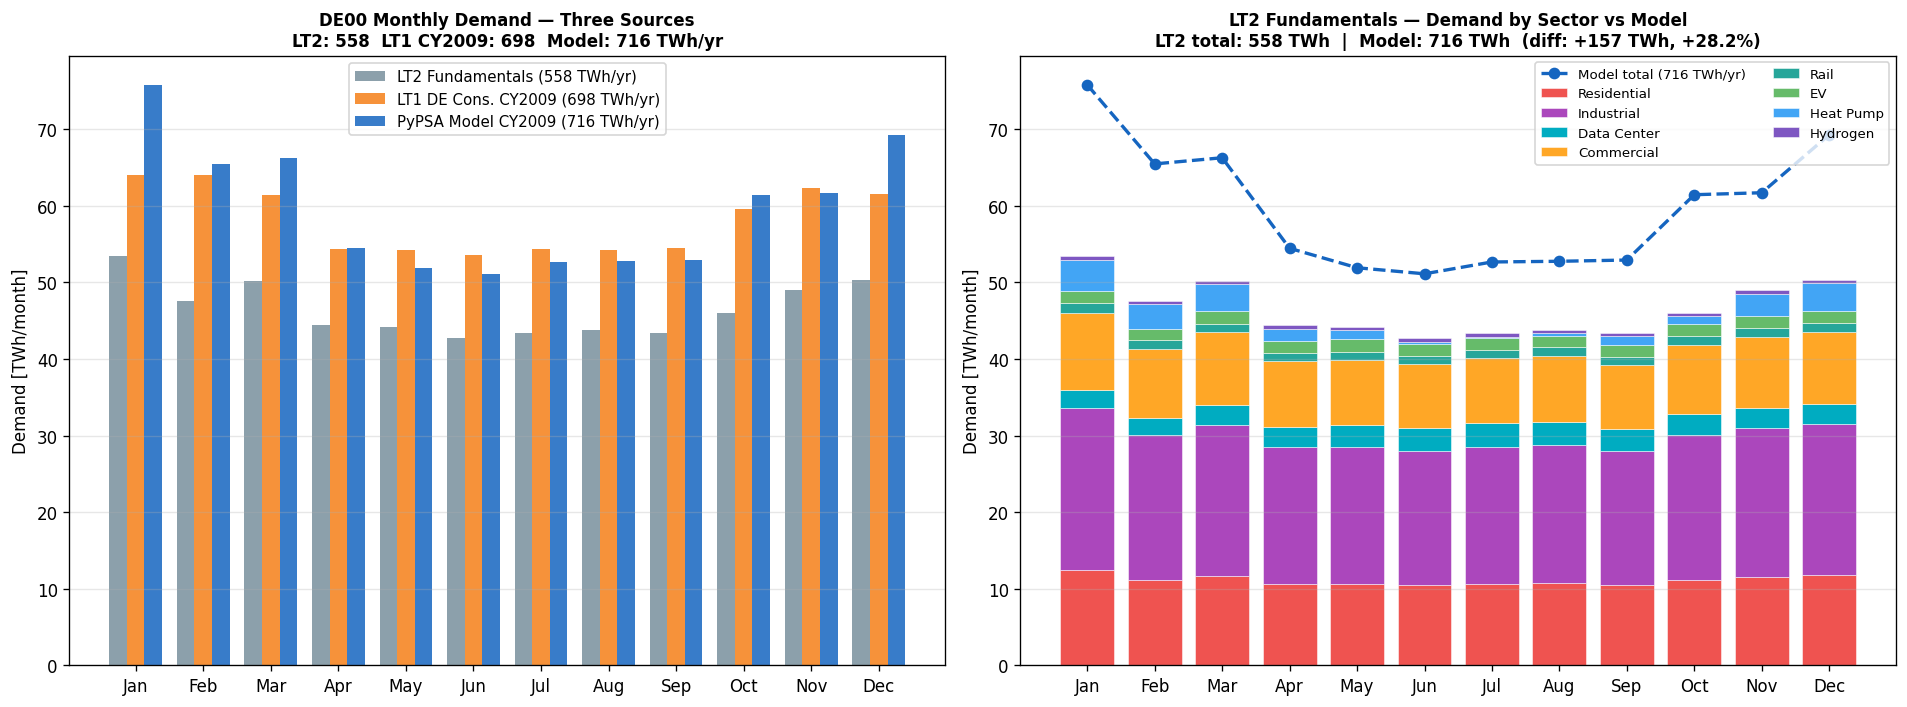


DE00 Monthly Demand Comparison:
  Month  LT2 Sectors  LT1 CY2009    Model   Mdl-LT2  Mdl-LT2%   Mdl-LT1  Mdl-LT1%
  --------------------------------------------------------------------------------
  Jan          53.41       64.09    75.81    +22.40    +41.9%    +11.72    +18.3%
  Feb          47.56       64.02    65.48    +17.92    +37.7%     +1.46     +2.3%
  Mar          50.24       61.44    66.29    +16.05    +31.9%     +4.84     +7.9%
  Apr          44.39       54.32    54.46    +10.07    +22.7%     +0.14     +0.3%
  May          44.18       54.29    51.92     +7.74    +17.5%     -2.37     -4.4%
  Jun          42.71       53.63    51.13     +8.42    +19.7%     -2.50     -4.7%
  Jul          43.44       54.41    52.68     +9.24    +21.3%     -1.74     -3.2%
  Aug          43.82       54.19    52.76     +8.94    +20.4%     -1.43     -2.6%
  Sep          43.43       54.45    52.93     +9.50    +21.9%     -1.52     -2.8%
  Oct          46.01       59.55    61.46    +15.45    +33.6%   

In [7]:
# --- Model demand ---
de_load_ts = n.loads_t.p_set["DE00-load"]
model_demand = np.array([
    float(de_load_ts[de_load_ts.index.month == m + 1].sum()) / 1e6
    for m in range(12)
])

# --- LT model.xlsx DE Consumption CY2009 ---
cons_raw = pd.read_excel(LT1_XLS, sheet_name="DE Consumption", header=None, engine="openpyxl")
# Row 0 = header (years); data starts row 1
# Find 2030 rows and column for CY2009
cons_header = cons_raw.iloc[0]
# Year column: col 0; find CY2009 column
cy2009_col = None
for ci, val in enumerate(cons_header):
    try:
        if float(val) == 2009.0:
            cy2009_col = ci
            break
    except (TypeError, ValueError):
        pass

cons_raw.columns = cons_raw.iloc[0]
cons_data = cons_raw.iloc[1:].copy().reset_index(drop=True)
cons_data["Date"] = pd.to_datetime(cons_data.iloc[:, 0], errors="coerce")
cons_2030 = cons_data[cons_data["Date"].dt.year == 2030].reset_index(drop=True)

cy2009_key = float(2009) if float(2009) in cons_data.columns else None
# Try integer 2009 key as well
for k in cons_data.columns:
    try:
        if int(float(k)) == 2009:
            cy2009_key = k
            break
    except (TypeError, ValueError):
        pass

lt1_demand = pd.to_numeric(cons_2030[cy2009_key], errors="coerce").fillna(0).values / 1000  # GWh → TWh

# --- LT model 2.xlsx Fundamentals demand sectors (cols 20–27) ---
DEMAND_SECTOR_COLS = {
    20: "Residential",
    21: "Industrial",
    22: "Data Center",
    23: "Commercial",
    24: "Rail",
    25: "EV",
    26: "Heat Pump",
    27: "Hydrogen",
}
lt2_demand = np.zeros(12)
lt2_sectors = {}
for ci, name in DEMAND_SECTOR_COLS.items():
    vals = pd.to_numeric(fund_2030.iloc[:, ci], errors="coerce").fillna(0).values / 1e6  # MWh → TWh
    lt2_sectors[name] = vals
    lt2_demand += vals

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: grouped bar — 3 sources per month
ax = axes[0]
x = np.arange(12); w = 0.26
ax.bar(x - w,   lt2_demand,    width=w, color="#78909C", alpha=0.85, label=f"LT2 Fundamentals ({lt2_demand.sum():.0f} TWh/yr)")
ax.bar(x,       lt1_demand,    width=w, color="#F57F17", alpha=0.85, label=f"LT1 DE Cons. CY2009 ({lt1_demand.sum():.0f} TWh/yr)")
ax.bar(x + w,   model_demand,  width=w, color="#1565C0", alpha=0.85, label=f"PyPSA Model CY2009 ({model_demand.sum():.0f} TWh/yr)")
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Demand [TWh/month]")
ax.set_title(
    f"DE00 Monthly Demand — Three Sources\n"
    f"LT2: {lt2_demand.sum():.0f}  LT1 CY2009: {lt1_demand.sum():.0f}  Model: {model_demand.sum():.0f} TWh/yr",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Right: LT2 stacked sector breakdown
ax2 = axes[1]
sector_colors = {
    "Residential": "#EF5350", "Industrial": "#AB47BC", "Data Center": "#00ACC1",
    "Commercial": "#FFA726", "Rail": "#26A69A", "EV": "#66BB6A",
    "Heat Pump": "#42A5F5", "Hydrogen": "#7E57C2",
}
bottom = np.zeros(12)
for sec, vals in lt2_sectors.items():
    ax2.bar(x, vals, bottom=bottom, color=sector_colors.get(sec, "#9E9E9E"),
            label=sec, edgecolor="white", linewidth=0.3)
    bottom += vals
ax2.plot(x, model_demand, "o--", color="#1565C0", linewidth=2, markersize=6,
         label=f"Model total ({model_demand.sum():.0f} TWh/yr)", zorder=5)
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel("Demand [TWh/month]")
ax2.set_title(
    f"LT2 Fundamentals — Demand by Sector vs Model\n"
    f"LT2 total: {lt2_demand.sum():.0f} TWh  |  Model: {model_demand.sum():.0f} TWh  "
    f"(diff: {model_demand.sum() - lt2_demand.sum():+.0f} TWh, "
    f"{100*(model_demand.sum()-lt2_demand.sum())/lt2_demand.sum():+.1f}%)",
    fontsize=10, fontweight="bold"
)
ax2.legend(fontsize=8, loc="upper right", ncol=2); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# --- Diff% table ---
print(f"\nDE00 Monthly Demand Comparison:")
print(f"  {'Month':<5} {'LT2 Sectors':>12} {'LT1 CY2009':>11} {'Model':>8}  "
      f"{'Mdl-LT2':>8} {'Mdl-LT2%':>9}  {'Mdl-LT1':>8} {'Mdl-LT1%':>9}")
print("  " + "-" * 80)
for i, mon in enumerate(MONTH_NAMES):
    lt2, lt1, mdl = lt2_demand[i], lt1_demand[i], model_demand[i]
    d2 = mdl - lt2;  p2 = 100 * d2 / lt2 if lt2 > 0 else float("nan")
    d1 = mdl - lt1;  p1 = 100 * d1 / lt1 if lt1 > 0 else float("nan")
    print(f"  {mon:<5} {lt2:12.2f} {lt1:11.2f} {mdl:8.2f}  "
          f"{d2:+8.2f} {p2:+8.1f}%  {d1:+8.2f} {p1:+8.1f}%")
lt2_t, lt1_t, mdl_t = lt2_demand.sum(), lt1_demand.sum(), model_demand.sum()
d2t = mdl_t - lt2_t; d1t = mdl_t - lt1_t
print(f"  {'Total':<5} {lt2_t:12.2f} {lt1_t:11.2f} {mdl_t:8.2f}  "
      f"{d2t:+8.2f} {100*d2t/lt2_t:+8.1f}%  {d1t:+8.2f} {100*d1t/lt1_t:+8.1f}%")

## Section 7 — DE Monthly Solar PV Generation

Three sources compared:
- **Model** — all Solar PV generators in DE00 (utility + rooftop), monthly sum [TWh]
- **LT model.xlsx DE RES** — `Solar` column, 2030 rows [TWh/month]
- **LT model 2.xlsx Fundamentals** — col 6 = Solar PV [MWh/month → TWh]

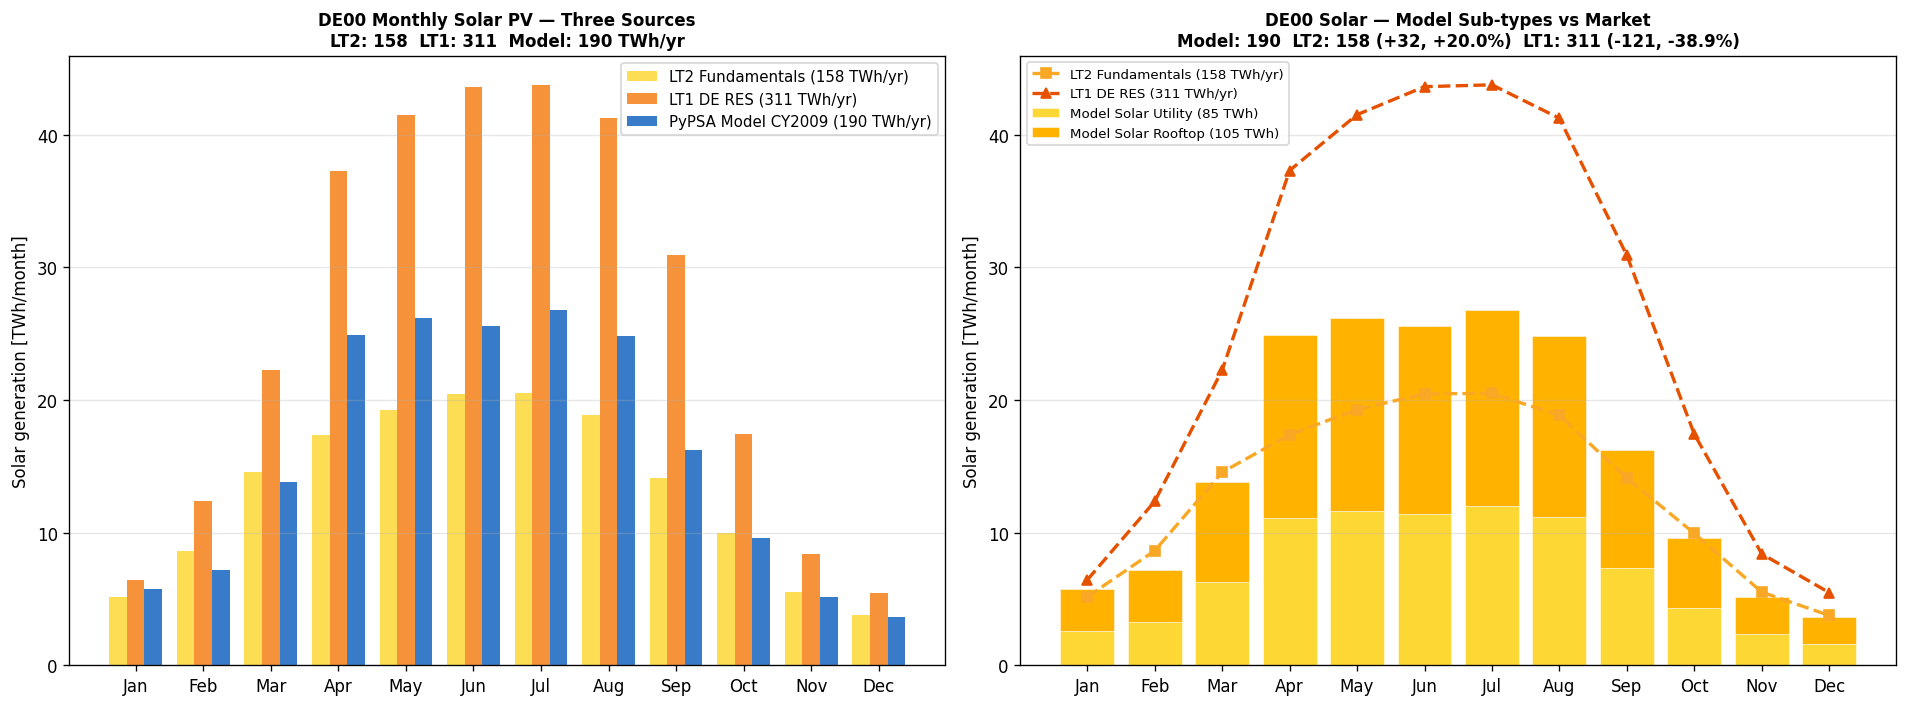


DE00 Monthly Solar Comparison:
  Month  LT2 [TWh]  LT1 [TWh] Model [TWh]   Mdl-LT2  Mdl-LT2%   Mdl-LT1  Mdl-LT1%
  --------------------------------------------------------------------------------
  Jan         5.15       6.44        5.75     +0.60    +11.6%     -0.69    -10.7%
  Feb         8.64      12.35        7.21     -1.43    -16.6%     -5.15    -41.7%
  Mar        14.55      22.24       13.85     -0.70     -4.8%     -8.39    -37.7%
  Apr        17.38      37.30       24.90     +7.52    +43.2%    -12.40    -33.2%
  May        19.28      41.51       26.16     +6.88    +35.7%    -15.35    -37.0%
  Jun        20.46      43.62       25.57     +5.11    +25.0%    -18.05    -41.4%
  Jul        20.50      43.76       26.79     +6.29    +30.7%    -16.96    -38.8%
  Aug        18.83      41.24       24.86     +6.02    +32.0%    -16.38    -39.7%
  Sep        14.11      30.90       16.21     +2.10    +14.8%    -14.69    -47.5%
  Oct         9.94      17.42        9.60     -0.35     -3.5%    

In [8]:
SOLAR_CARRIERS = {"solar-pv-utility", "solar-pv-rooftop", "solar-thermal", "solar-thermal-w-storage"}
SOLAR_SUBTYPES = {
    "solar-pv-utility":        "Solar Utility",
    "solar-pv-rooftop":        "Solar Rooftop",
    "solar-thermal":           "Solar Thermal",
    "solar-thermal-w-storage": "Solar Thermal",
}
SOLAR_COLORS = {
    "Solar Utility":  "#FDD835",
    "Solar Rooftop":  "#FFB300",
    "Solar Thermal":  "#FF8F00",
}

# --- Model solar monthly [TWh] ---
model_solar_total = np.zeros(12)
model_solar_sub   = {}
for gen_id, g in n.generators.iterrows():
    if g["bus"] != BUS or g["carrier"] not in SOLAR_CARRIERS: continue
    if gen_id not in n.generators_t.p.columns: continue
    sub = SOLAR_SUBTYPES[g["carrier"]]
    ts  = n.generators_t.p[gen_id]
    model_solar_sub.setdefault(sub, np.zeros(12))
    for mo in range(12):
        val = float(ts[ts.index.month == mo + 1].sum()) / 1e6
        model_solar_sub[sub][mo] += val
        model_solar_total[mo]    += val

# --- LT model.xlsx DE RES — Solar column [TWh] ---
res_raw = pd.read_excel(LT1_XLS, sheet_name="DE RES", header=None, engine="openpyxl")
res_raw.columns = res_raw.iloc[0]
res_raw = res_raw.iloc[1:].copy().reset_index(drop=True)
res_raw["Date"] = pd.to_datetime(res_raw["Date"], errors="coerce")
res_2030 = res_raw[res_raw["Date"].dt.year == 2030].reset_index(drop=True)
lt1_solar = pd.to_numeric(res_2030["Solar"], errors="coerce").fillna(0).values  # already TWh

# --- LT model 2.xlsx Fundamentals col 6 — Solar PV [MWh → TWh] ---
lt2_solar = pd.to_numeric(fund_2030.iloc[:, 6], errors="coerce").fillna(0).values / 1e6

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(12)

# Left: grouped bar — 3 sources
ax = axes[0]
w = 0.26
ax.bar(x - w, lt2_solar,        width=w, color="#FDD835", alpha=0.85, label=f"LT2 Fundamentals ({lt2_solar.sum():.0f} TWh/yr)")
ax.bar(x,     lt1_solar,        width=w, color="#F57F17", alpha=0.85, label=f"LT1 DE RES ({lt1_solar.sum():.0f} TWh/yr)")
ax.bar(x + w, model_solar_total, width=w, color="#1565C0", alpha=0.85, label=f"PyPSA Model CY2009 ({model_solar_total.sum():.0f} TWh/yr)")
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Solar generation [TWh/month]")
ax.set_title(
    f"DE00 Monthly Solar PV — Three Sources\n"
    f"LT2: {lt2_solar.sum():.0f}  LT1: {lt1_solar.sum():.0f}  Model: {model_solar_total.sum():.0f} TWh/yr",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Right: model sub-type stacked + LT2 line
ax2 = axes[1]
bottom = np.zeros(12)
for sub, vals in model_solar_sub.items():
    ax2.bar(x, vals, bottom=bottom, color=SOLAR_COLORS.get(sub, "#9E9E9E"),
            label=f"Model {sub} ({vals.sum():.0f} TWh)", edgecolor="white", linewidth=0.3)
    bottom += vals
ax2.plot(x, lt2_solar, "s--", color="#F9A825", linewidth=2, markersize=6,
         label=f"LT2 Fundamentals ({lt2_solar.sum():.0f} TWh/yr)", zorder=5)
ax2.plot(x, lt1_solar, "^--", color="#E65100", linewidth=2, markersize=6,
         label=f"LT1 DE RES ({lt1_solar.sum():.0f} TWh/yr)", zorder=5)
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel("Solar generation [TWh/month]")
diff_lt2 = model_solar_total.sum() - lt2_solar.sum()
diff_lt1 = model_solar_total.sum() - lt1_solar.sum()
ax2.set_title(
    f"DE00 Solar — Model Sub-types vs Market\n"
    f"Model: {model_solar_total.sum():.0f}  LT2: {lt2_solar.sum():.0f} ({diff_lt2:+.0f}, {100*diff_lt2/lt2_solar.sum():+.1f}%)  "
    f"LT1: {lt1_solar.sum():.0f} ({diff_lt1:+.0f}, {100*diff_lt1/lt1_solar.sum():+.1f}%)",
    fontsize=10, fontweight="bold"
)
ax2.legend(fontsize=8, loc="upper left"); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# --- Diff% table ---
print(f"\nDE00 Monthly Solar Comparison:")
print(f"  {'Month':<5} {'LT2 [TWh]':>10} {'LT1 [TWh]':>10} {'Model [TWh]':>11}  "
      f"{'Mdl-LT2':>8} {'Mdl-LT2%':>9}  {'Mdl-LT1':>8} {'Mdl-LT1%':>9}")
print("  " + "-" * 80)
for i, mon in enumerate(MONTH_NAMES):
    lt2, lt1, mdl = lt2_solar[i], lt1_solar[i], model_solar_total[i]
    d2 = mdl - lt2;  p2 = 100 * d2 / lt2 if lt2 > 0 else float("nan")
    d1 = mdl - lt1;  p1 = 100 * d1 / lt1 if lt1 > 0 else float("nan")
    print(f"  {mon:<5} {lt2:10.2f} {lt1:10.2f} {mdl:11.2f}  "
          f"{d2:+8.2f} {p2:+8.1f}%  {d1:+8.2f} {p1:+8.1f}%")
lt2_t, lt1_t, mdl_t = lt2_solar.sum(), lt1_solar.sum(), model_solar_total.sum()
d2t = mdl_t - lt2_t; d1t = mdl_t - lt1_t
print(f"  {'Total':<5} {lt2_t:10.2f} {lt1_t:10.2f} {mdl_t:11.2f}  "
      f"{d2t:+8.2f} {100*d2t/lt2_t:+8.1f}%  {d1t:+8.2f} {100*d1t/lt1_t:+8.1f}%")

## Section 8 — DE Monthly Wind Generation (Onshore + Offshore combined)

Three sources compared:
- **Model** — all Wind generators in DE00 (onshore + offshore), monthly sum [TWh]
- **LT model.xlsx DE RES** — `Onshore wind` + `Offshore wind` columns, 2030 rows [TWh/month]
- **LT model 2.xlsx Fundamentals** — col 7 (Wind Onshore) + col 8 (Wind Offshore) [MWh/month → TWh]

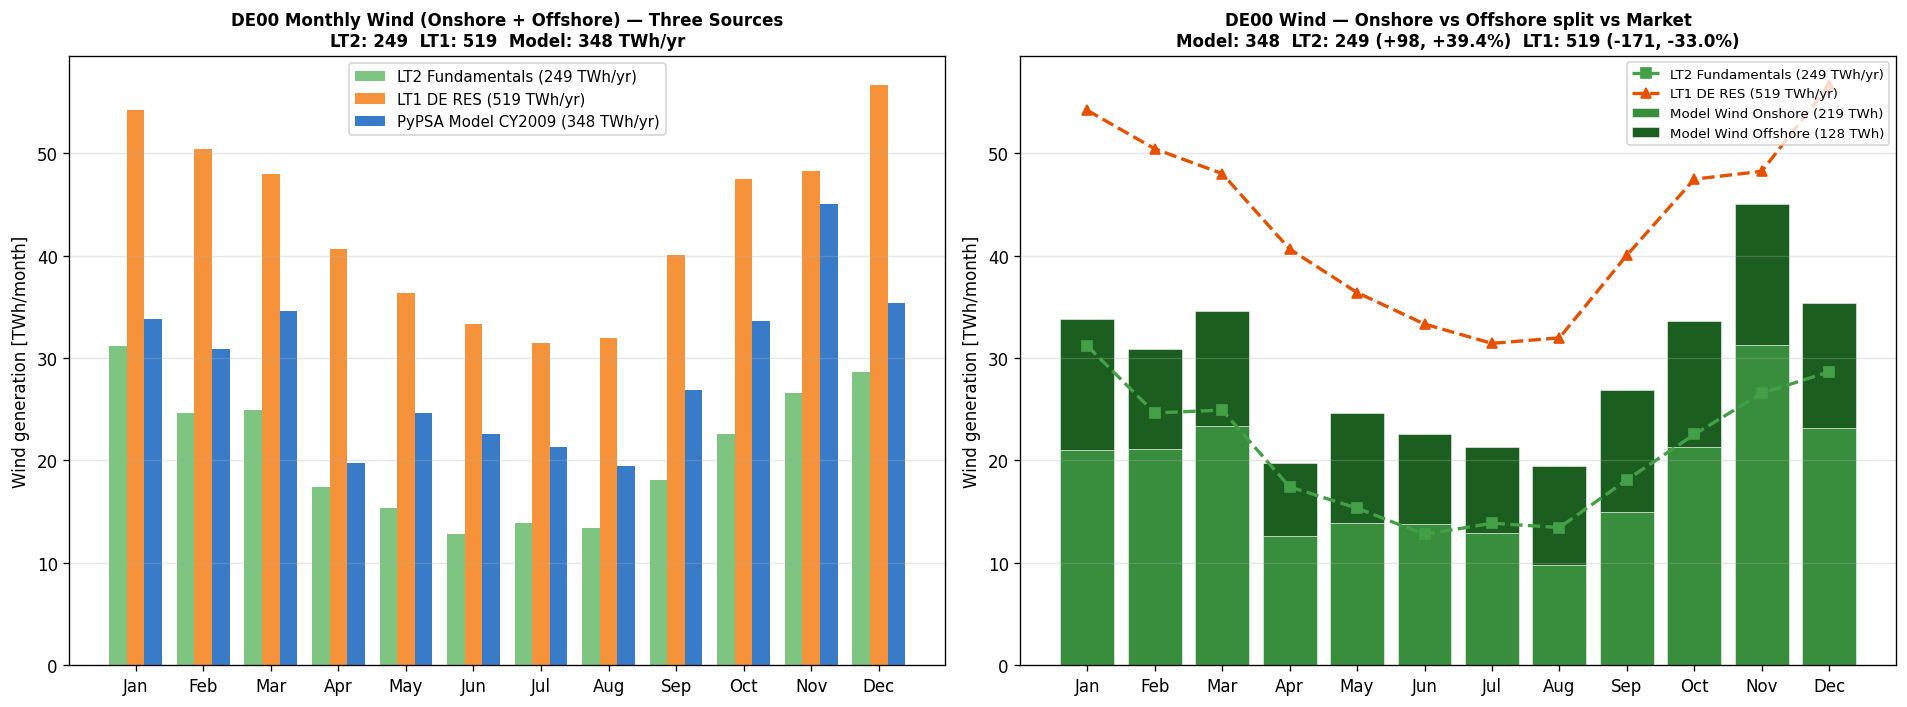


DE00 Monthly Wind Comparison (Onshore + Offshore):
  Month  LT2 [TWh]  LT1 [TWh] Model [TWh]   Mdl-LT2  Mdl-LT2%   Mdl-LT1  Mdl-LT1%
  --------------------------------------------------------------------------------
  Jan        31.19      54.18       33.78     +2.59     +8.3%    -20.41    -37.7%
  Feb        24.64      50.43       30.84     +6.20    +25.2%    -19.59    -38.8%
  Mar        24.92      48.01       34.55     +9.63    +38.7%    -13.46    -28.0%
  Apr        17.43      40.64       19.75     +2.33    +13.4%    -20.89    -51.4%
  May        15.35      36.39       24.66     +9.31    +60.7%    -11.74    -32.2%
  Jun        12.78      33.32       22.60     +9.82    +76.9%    -10.72    -32.2%
  Jul        13.87      31.43       21.32     +7.44    +53.7%    -10.12    -32.2%
  Aug        13.45      31.97       19.48     +6.03    +44.8%    -12.49    -39.1%
  Sep        18.11      40.04       26.87     +8.76    +48.4%    -13.17    -32.9%
  Oct        22.54      47.46       33.63    

In [9]:
WIND_CARRIERS = {"onwind": "Wind Onshore", "offwind": "Wind Offshore"}
WIND_COLORS   = {"Wind Onshore": "#388E3C", "Wind Offshore": "#1B5E20"}

# --- Model wind monthly [TWh] ---
model_wind_total = np.zeros(12)
model_wind_sub   = {}
for gen_id, g in n.generators.iterrows():
    if g["bus"] != BUS or g["carrier"] not in WIND_CARRIERS: continue
    if gen_id not in n.generators_t.p.columns: continue
    sub = WIND_CARRIERS[g["carrier"]]
    ts  = n.generators_t.p[gen_id]
    model_wind_sub.setdefault(sub, np.zeros(12))
    for mo in range(12):
        val = float(ts[ts.index.month == mo + 1].sum()) / 1e6
        model_wind_sub[sub][mo] += val
        model_wind_total[mo]    += val

# --- LT model.xlsx DE RES — Onshore + Offshore [TWh] ---
lt1_wind = (
    pd.to_numeric(res_2030["Onshore wind"], errors="coerce").fillna(0).values
    + pd.to_numeric(res_2030["Offshore wind"], errors="coerce").fillna(0).values
)

# --- LT model 2.xlsx Fundamentals col 7 + col 8 [MWh → TWh] ---
lt2_wind = (
    pd.to_numeric(fund_2030.iloc[:, 7], errors="coerce").fillna(0).values / 1e6
    + pd.to_numeric(fund_2030.iloc[:, 8], errors="coerce").fillna(0).values / 1e6
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(12)

# Left: grouped bar — 3 sources
ax = axes[0]
w = 0.26
ax.bar(x - w, lt2_wind,        width=w, color="#66BB6A", alpha=0.85, label=f"LT2 Fundamentals ({lt2_wind.sum():.0f} TWh/yr)")
ax.bar(x,     lt1_wind,        width=w, color="#F57F17", alpha=0.85, label=f"LT1 DE RES ({lt1_wind.sum():.0f} TWh/yr)")
ax.bar(x + w, model_wind_total, width=w, color="#1565C0", alpha=0.85, label=f"PyPSA Model CY2009 ({model_wind_total.sum():.0f} TWh/yr)")
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Wind generation [TWh/month]")
ax.set_title(
    f"DE00 Monthly Wind (Onshore + Offshore) — Three Sources\n"
    f"LT2: {lt2_wind.sum():.0f}  LT1: {lt1_wind.sum():.0f}  Model: {model_wind_total.sum():.0f} TWh/yr",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Right: model split onshore/offshore stacked + market lines
ax2 = axes[1]
bottom = np.zeros(12)
for sub in ["Wind Onshore", "Wind Offshore"]:
    if sub not in model_wind_sub: continue
    vals = model_wind_sub[sub]
    ax2.bar(x, vals, bottom=bottom, color=WIND_COLORS[sub],
            label=f"Model {sub} ({vals.sum():.0f} TWh)", edgecolor="white", linewidth=0.3)
    bottom += vals
ax2.plot(x, lt2_wind, "s--", color="#43A047", linewidth=2, markersize=6,
         label=f"LT2 Fundamentals ({lt2_wind.sum():.0f} TWh/yr)", zorder=5)
ax2.plot(x, lt1_wind, "^--", color="#E65100", linewidth=2, markersize=6,
         label=f"LT1 DE RES ({lt1_wind.sum():.0f} TWh/yr)", zorder=5)
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel("Wind generation [TWh/month]")
diff_lt2 = model_wind_total.sum() - lt2_wind.sum()
diff_lt1 = model_wind_total.sum() - lt1_wind.sum()
ax2.set_title(
    f"DE00 Wind — Onshore vs Offshore split vs Market\n"
    f"Model: {model_wind_total.sum():.0f}  LT2: {lt2_wind.sum():.0f} ({diff_lt2:+.0f}, {100*diff_lt2/lt2_wind.sum():+.1f}%)  "
    f"LT1: {lt1_wind.sum():.0f} ({diff_lt1:+.0f}, {100*diff_lt1/lt1_wind.sum():+.1f}%)",
    fontsize=10, fontweight="bold"
)
ax2.legend(fontsize=8, loc="upper right"); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# --- Diff% table ---
print(f"\nDE00 Monthly Wind Comparison (Onshore + Offshore):")
print(f"  {'Month':<5} {'LT2 [TWh]':>10} {'LT1 [TWh]':>10} {'Model [TWh]':>11}  "
      f"{'Mdl-LT2':>8} {'Mdl-LT2%':>9}  {'Mdl-LT1':>8} {'Mdl-LT1%':>9}")
print("  " + "-" * 80)
for i, mon in enumerate(MONTH_NAMES):
    lt2, lt1, mdl = lt2_wind[i], lt1_wind[i], model_wind_total[i]
    d2 = mdl - lt2;  p2 = 100 * d2 / lt2 if lt2 > 0 else float("nan")
    d1 = mdl - lt1;  p1 = 100 * d1 / lt1 if lt1 > 0 else float("nan")
    print(f"  {mon:<5} {lt2:10.2f} {lt1:10.2f} {mdl:11.2f}  "
          f"{d2:+8.2f} {p2:+8.1f}%  {d1:+8.2f} {p1:+8.1f}%")
lt2_t, lt1_t, mdl_t = lt2_wind.sum(), lt1_wind.sum(), model_wind_total.sum()
d2t = mdl_t - lt2_t; d1t = mdl_t - lt1_t
print(f"  {'Total':<5} {lt2_t:10.2f} {lt1_t:10.2f} {mdl_t:11.2f}  "
      f"{d2t:+8.2f} {100*d2t/lt2_t:+8.1f}%  {d1t:+8.2f} {100*d1t/lt1_t:+8.1f}%")

## Section 9 — DE Monthly Gas Generation

Sources compared:
- **Model** — all gas carriers in DE00 (`gas`, `gas-ccs`, `h2-ccgt`, `h2-fuel-cell`), monthly sum [TWh]
- **LT model 2.xlsx Fundamentals** — col 12 (CCS Gas) + col 13 (Gas) [MWh/month → TWh]
- **LT model.xlsx DE Power Generation** — `Gas` row, 2030 column [annual TWh only → shown as reference line]

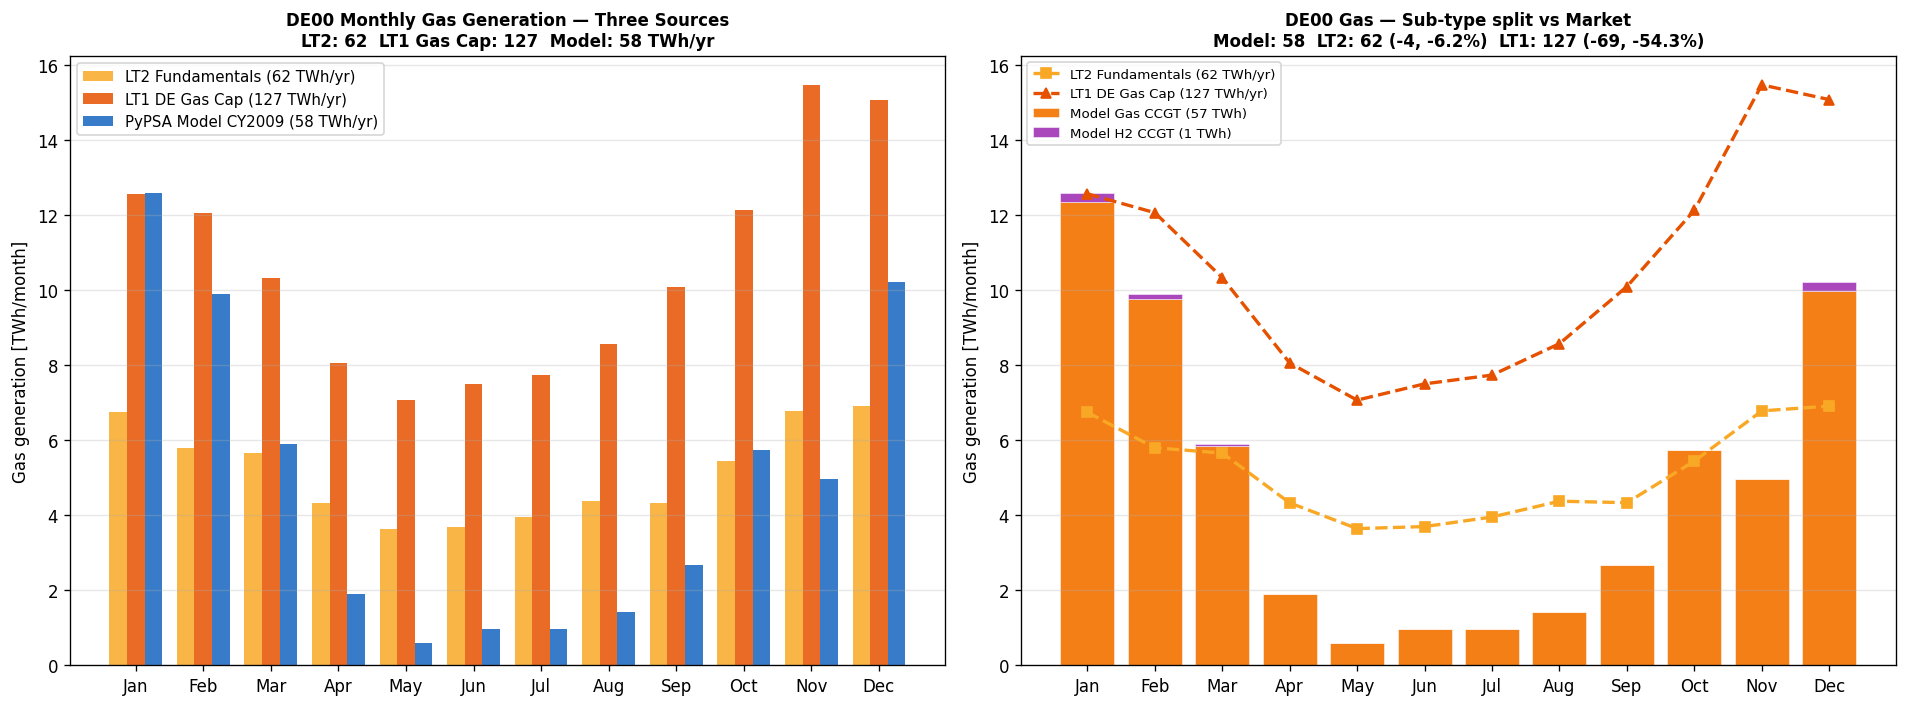


DE00 Monthly Gas Comparison:
  Month  LT2 [TWh]  LT1 [TWh] Model [TWh]   Mdl-LT2  Mdl-LT2%   Mdl-LT1  Mdl-LT1%
  --------------------------------------------------------------------------------
  Jan         6.74      12.57       12.59     +5.84    +86.6%     +0.02     +0.1%
  Feb         5.80      12.07        9.90     +4.10    +70.6%     -2.17    -18.0%
  Mar         5.66      10.33        5.89     +0.23     +4.1%     -4.44    -43.0%
  Apr         4.33       8.06        1.91     -2.43    -56.0%     -6.15    -76.4%
  May         3.65       7.07        0.59     -3.06    -83.9%     -6.48    -91.7%
  Jun         3.70       7.50        0.98     -2.72    -73.5%     -6.52    -86.9%
  Jul         3.95       7.74        0.98     -2.98    -75.3%     -6.76    -87.4%
  Aug         4.38       8.58        1.41     -2.96    -67.7%     -7.16    -83.5%
  Sep         4.34      10.10        2.68     -1.65    -38.1%     -7.41    -73.4%
  Oct         5.44      12.13        5.75     +0.31     +5.7%     -

In [11]:
GAS_CARRIERS = {
    "gas":          "Gas CCGT",
    "gas-ccs":      "Gas CCS",
    "h2-ccgt":      "H2 CCGT",
    "h2-fuel-cell": "H2 Fuel Cell",
}
GAS_COLORS = {
    "Gas CCGT":      "#F57F17",
    "Gas CCS":       "#E65100",
    "H2 CCGT":       "#AB47BC",
    "H2 Fuel Cell":  "#CE93D8",
}

# --- Model gas monthly [TWh] ---
model_gas_total = np.zeros(12)
model_gas_sub   = {}
for gen_id, g in n.generators.iterrows():
    if g["bus"] != BUS or g["carrier"] not in GAS_CARRIERS: continue
    if gen_id not in n.generators_t.p.columns: continue
    sub = GAS_CARRIERS[g["carrier"]]
    ts  = n.generators_t.p[gen_id]
    model_gas_sub.setdefault(sub, np.zeros(12))
    for mo in range(12):
        val = float(ts[ts.index.month == mo + 1].sum()) / 1e6
        model_gas_sub[sub][mo] += val
        model_gas_total[mo]    += val

# --- LT model 2.xlsx Fundamentals col 12 (CCS Gas) + col 13 (Gas) [MWh → TWh] ---
lt2_gas = (
    pd.to_numeric(fund_2030.iloc[:, 12], errors="coerce").fillna(0).values / 1e6
    + pd.to_numeric(fund_2030.iloc[:, 13], errors="coerce").fillna(0).values / 1e6
)

# --- LT model.xlsx DE Gas Cap — Forward generation [GWh/month → TWh] ---
gc_raw = pd.read_excel(LT1_XLS, sheet_name="DE Gas Cap", header=None, engine="openpyxl")
gc_raw.columns = gc_raw.iloc[0]
gc_raw = gc_raw.iloc[1:].copy()
gc_raw["Date"] = pd.to_datetime(gc_raw["Date"], errors="coerce")
gc_2030 = gc_raw[gc_raw["Date"].dt.year == 2030].reset_index(drop=True)
lt1_gas = pd.to_numeric(gc_2030["Forward generation"], errors="coerce").fillna(0).values / 1000  # GWh → TWh

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(12)

# Left: grouped bar — 3 sources
ax = axes[0]
w = 0.26
ax.bar(x - w, lt2_gas,        width=w, color="#F9A825", alpha=0.85, label=f"LT2 Fundamentals ({lt2_gas.sum():.0f} TWh/yr)")
ax.bar(x,     lt1_gas,        width=w, color="#E65100", alpha=0.85, label=f"LT1 DE Gas Cap ({lt1_gas.sum():.0f} TWh/yr)")
ax.bar(x + w, model_gas_total, width=w, color="#1565C0", alpha=0.85, label=f"PyPSA Model CY2009 ({model_gas_total.sum():.0f} TWh/yr)")
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Gas generation [TWh/month]")
ax.set_title(
    f"DE00 Monthly Gas Generation — Three Sources\n"
    f"LT2: {lt2_gas.sum():.0f}  LT1 Gas Cap: {lt1_gas.sum():.0f}  Model: {model_gas_total.sum():.0f} TWh/yr",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Right: model sub-type stacked + market lines
ax2 = axes[1]
bottom = np.zeros(12)
for sub in ["Gas CCGT", "Gas CCS", "H2 CCGT", "H2 Fuel Cell"]:
    if sub not in model_gas_sub: continue
    vals = model_gas_sub[sub]
    if vals.sum() < 0.01: continue
    ax2.bar(x, vals, bottom=bottom, color=GAS_COLORS[sub],
            label=f"Model {sub} ({vals.sum():.0f} TWh)", edgecolor="white", linewidth=0.3)
    bottom += vals
ax2.plot(x, lt2_gas, "s--", color="#F9A825", linewidth=2, markersize=6,
         label=f"LT2 Fundamentals ({lt2_gas.sum():.0f} TWh/yr)", zorder=5)
ax2.plot(x, lt1_gas, "^--", color="#E65100", linewidth=2, markersize=6,
         label=f"LT1 DE Gas Cap ({lt1_gas.sum():.0f} TWh/yr)", zorder=5)
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel("Gas generation [TWh/month]")
diff_lt2 = model_gas_total.sum() - lt2_gas.sum()
diff_lt1 = model_gas_total.sum() - lt1_gas.sum()
ax2.set_title(
    f"DE00 Gas — Sub-type split vs Market\n"
    f"Model: {model_gas_total.sum():.0f}  LT2: {lt2_gas.sum():.0f} ({diff_lt2:+.0f}, {100*diff_lt2/lt2_gas.sum():+.1f}%)  "
    f"LT1: {lt1_gas.sum():.0f} ({diff_lt1:+.0f}, {100*diff_lt1/lt1_gas.sum():+.1f}%)",
    fontsize=10, fontweight="bold"
)
ax2.legend(fontsize=8, loc="upper left"); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# --- Diff% table ---
print(f"\nDE00 Monthly Gas Comparison:")
print(f"  {'Month':<5} {'LT2 [TWh]':>10} {'LT1 [TWh]':>10} {'Model [TWh]':>11}  "
      f"{'Mdl-LT2':>8} {'Mdl-LT2%':>9}  {'Mdl-LT1':>8} {'Mdl-LT1%':>9}")
print("  " + "-" * 80)
for i, mon in enumerate(MONTH_NAMES):
    lt2, lt1, mdl = lt2_gas[i], lt1_gas[i], model_gas_total[i]
    d2 = mdl - lt2;  p2 = 100 * d2 / lt2 if lt2 > 0 else float("nan")
    d1 = mdl - lt1;  p1 = 100 * d1 / lt1 if lt1 > 0 else float("nan")
    print(f"  {mon:<5} {lt2:10.2f} {lt1:10.2f} {mdl:11.2f}  "
          f"{d2:+8.2f} {p2:+8.1f}%  {d1:+8.2f} {p1:+8.1f}%")
lt2_t, lt1_t, mdl_t = lt2_gas.sum(), lt1_gas.sum(), model_gas_total.sum()
d2t = mdl_t - lt2_t; d1t = mdl_t - lt1_t
print(f"  {'Total':<5} {lt2_t:10.2f} {lt1_t:10.2f} {mdl_t:11.2f}  "
      f"{d2t:+8.2f} {100*d2t/lt2_t:+8.1f}%  {d1t:+8.2f} {100*d1t/lt1_t:+8.1f}%")